# 🚢 Titanic Dataset - Exploratory Data Analysis (EDA)
## Task 1: Data Scientist ka Toolkit Setup aur First Analysis
---

## Step 1: Libraries Install & Import
**Note**: Google Colab mein sab libraries already installed hain! Sirf import karo.

In [1]:
# Essential Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Matplotlib settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Sab libraries load hogai!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Sab libraries load hogai!
Pandas version: 2.2.2
NumPy version: 2.0.2


## Step 2: Dataset Upload Karo (Colab ke liye)
**Option A: Colab Files se upload karo** (recommended)

In [2]:
# Google Colab mein file upload karo
from google.colab import files

print("📁 CSV file upload karo (titanic.csv)...")
uploaded = files.upload()

# File ko load karo
df = pd.read_csv('titanic.csv')
print(f"✅ Dataset loaded! Shape: {df.shape}")

📁 CSV file upload karo (titanic.csv)...


Saving titanic.csv to titanic.csv
✅ Dataset loaded! Shape: (891, 12)


**Option B: Agar directly access karna ho**

In [ ]:
# Agar file already mount ho
# df = pd.read_csv('/path/to/titanic.csv')

# Ya Kaggle se directly (agar API setup ho)
# !kaggle datasets download -d titanic
# df = pd.read_csv('train.csv')

---
## Step 3: Dataset ka First Look
### 3.1 Shape aur Columns

In [3]:
print("="*60)
print("📊 DATASET KA SHAPE")
print("="*60)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

📊 DATASET KA SHAPE
Total Rows: 891
Total Columns: 12

Column Names:
  1. PassengerId
  2. Survived
  3. Pclass
  4. Name
  5. Sex
  6. Age
  7. SibSp
  8. Parch
  9. Ticket
  10. Fare
  11. Cabin
  12. Embarked


### 3.2 First 5 Rows Dekho

In [4]:
print("\n" + "="*60)
print("👀 FIRST 5 ROWS")
print("="*60)
df.head()


👀 FIRST 5 ROWS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3.3 Last 5 Rows

In [5]:
print("\n" + "="*60)
print("👀 LAST 5 ROWS")
print("="*60)
df.tail()


👀 LAST 5 ROWS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


---
## Step 4: Data Types aur Info
### 4.1 DataFrame Info (Missing Values Check)

In [6]:
print("\n" + "="*60)
print("🔍 DETAILED DATA INFO")
print("="*60)
df.info()


🔍 DETAILED DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 4.2 Missing Values Summary

In [7]:
print("\n" + "="*60)
print("❌ MISSING VALUES ANALYSIS")
print("="*60)

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_percent
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

if len(missing_df) == 0:
    print("✅ Koi missing values nahi!")
else:
    print(f"\n⚠️ Total {len(missing_df)} columns mein missing values hain")


❌ MISSING VALUES ANALYSIS
          Missing_Count  Percentage
Cabin               687   77.104377
Age                 177   19.865320
Embarked              2    0.224467

⚠️ Total 3 columns mein missing values hain


---
## Step 5: Statistical Summary
### 5.1 Numerical Columns ka Statistics

In [8]:
print("\n" + "="*60)
print("📈 NUMERICAL COLUMNS - STATISTICS")
print("="*60)
df.describe()


📈 NUMERICAL COLUMNS - STATISTICS


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 5.2 Categorical Columns Summary

In [9]:
print("\n" + "="*60)
print("🏷️ CATEGORICAL COLUMNS - SUMMARY")
print("="*60)
df.describe(include=['object'])


🏷️ CATEGORICAL COLUMNS - SUMMARY


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


---
## Step 6: Column Types Classification

In [10]:
print("\n" + "="*60)
print("🔀 NUMERICAL vs CATEGORICAL CLASSIFICATION")
print("="*60)

# Numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n🔢 NUMERICAL COLUMNS ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  • {col}")

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n🏷️ CATEGORICAL COLUMNS ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  • {col}")


🔀 NUMERICAL vs CATEGORICAL CLASSIFICATION

🔢 NUMERICAL COLUMNS (7):
  • PassengerId
  • Survived
  • Pclass
  • Age
  • SibSp
  • Parch
  • Fare

🏷️ CATEGORICAL COLUMNS (5):
  • Name
  • Sex
  • Ticket
  • Cabin
  • Embarked


---
## Step 7: Detailed Column-wise Analysis

In [11]:
print("\n" + "="*60)
print("🔬 COLUMN-WISE DETAILED ANALYSIS")
print("="*60)

for col in df.columns:
    print(f"\n📍 Column: {col}")
    print(f"   Data Type: {df[col].dtype}")
    print(f"   Non-Null Count: {df[col].notna().sum()}")
    print(f"   Null Count: {df[col].isna().sum()}")
    print(f"   Null %: {(df[col].isna().sum() / len(df)) * 100:.2f}%")

    if df[col].dtype == 'object':
        print(f"   Unique Values: {df[col].nunique()}")
        print(f"   Sample Values: {df[col].unique()[:5].tolist()}")
    else:
        print(f"   Min: {df[col].min()}, Max: {df[col].max()}")
        print(f"   Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")


🔬 COLUMN-WISE DETAILED ANALYSIS

📍 Column: PassengerId
   Data Type: int64
   Non-Null Count: 891
   Null Count: 0
   Null %: 0.00%
   Min: 1, Max: 891
   Mean: 446.00, Median: 446.00

📍 Column: Survived
   Data Type: int64
   Non-Null Count: 891
   Null Count: 0
   Null %: 0.00%
   Min: 0, Max: 1
   Mean: 0.38, Median: 0.00

📍 Column: Pclass
   Data Type: int64
   Non-Null Count: 891
   Null Count: 0
   Null %: 0.00%
   Min: 1, Max: 3
   Mean: 2.31, Median: 3.00

📍 Column: Name
   Data Type: object
   Non-Null Count: 891
   Null Count: 0
   Null %: 0.00%
   Unique Values: 891
   Sample Values: ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry']

📍 Column: Sex
   Data Type: object
   Non-Null Count: 891
   Null Count: 0
   Null %: 0.00%
   Unique Values: 2
   Sample Values: ['male', 'female']

📍 Column: Age
   Data Type: float64
   Non-Null Count: 714
  

---
## Step 8: Data Quality Check

In [12]:
print("\n" + "="*60)
print("⚠️ DATA QUALITY CHECKS")
print("="*60)

# Duplicates
print(f"\n1️⃣ DUPLICATES:")
duplicates = df.duplicated().sum()
print(f"   Duplicate Rows: {duplicates}")
if duplicates > 0:
    print(f"   ⚠️ {duplicates} duplicate rows found!")
else:
    print(f"   ✅ No duplicates")

# Memory usage
print(f"\n2️⃣ MEMORY USAGE:")
print(f"   Total Memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Data completeness
completeness = (df.notna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"\n3️⃣ DATA COMPLETENESS:")
print(f"   {completeness:.2f}% cells filled")


⚠️ DATA QUALITY CHECKS

1️⃣ DUPLICATES:
   Duplicate Rows: 0
   ✅ No duplicates

2️⃣ MEMORY USAGE:
   Total Memory: 285.61 KB

3️⃣ DATA COMPLETENESS:
   91.90% cells filled


---
## Step 9: Key Statistics - Target Variable (Survived)


🎯 TARGET VARIABLE ANALYSIS (Survived)

Survival Distribution:
  Did NOT Survive (0): 549 (61.62%)
  Survived (1): 342 (38.38%)


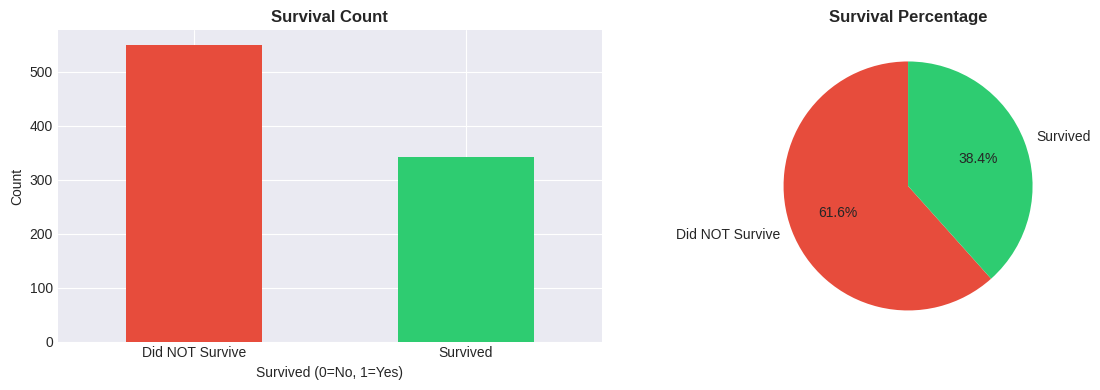

In [13]:
print("\n" + "="*60)
print("🎯 TARGET VARIABLE ANALYSIS (Survived)")
print("="*60)

survived_counts = df['Survived'].value_counts()
survived_pct = df['Survived'].value_counts(normalize=True) * 100

print(f"\nSurvival Distribution:")
print(f"  Did NOT Survive (0): {survived_counts[0]} ({survived_pct[0]:.2f}%)")
print(f"  Survived (1): {survived_counts[1]} ({survived_pct[1]:.2f}%)")

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
survived_counts.plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'])
ax[0].set_title('Survival Count', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Survived (0=No, 1=Yes)')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['Did NOT Survive', 'Survived'], rotation=0)

# Pie chart
ax[1].pie(survived_counts, labels=['Did NOT Survive', 'Survived'], autopct='%1.1f%%',
          colors=['#e74c3c', '#2ecc71'], startangle=90)
ax[1].set_title('Survival Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 10: Visualizations - Explore Relationships


📊 KEY INSIGHTS - VISUALIZATIONS


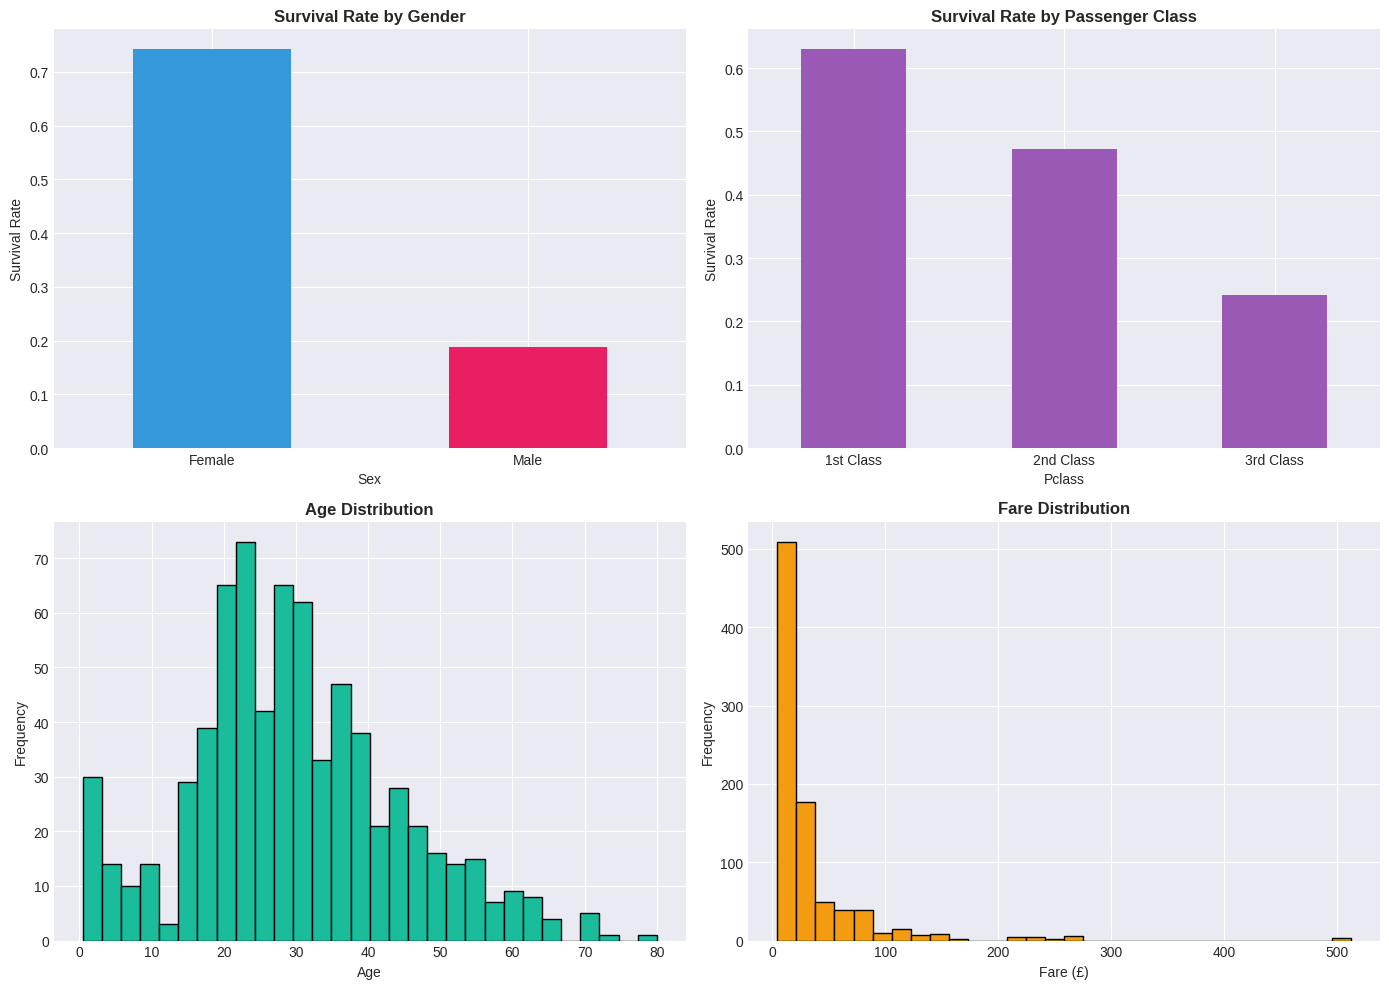

In [14]:
print("\n" + "="*60)
print("📊 KEY INSIGHTS - VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival by Sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e91e63'])
axes[0, 0].set_title('Survival Rate by Gender', fontweight='bold')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_xticklabels(['Female', 'Male'], rotation=0)

# 2. Survival by Passenger Class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0, 1], color='#9b59b6')
axes[0, 1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)

# 3. Age Distribution
df['Age'].hist(bins=30, ax=axes[1, 0], color='#1abc9c', edgecolor='black')
axes[1, 0].set_title('Age Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')

# 4. Fare Distribution (log scale)
df[df['Fare'] > 0]['Fare'].hist(bins=30, ax=axes[1, 1], color='#f39c12', edgecolor='black')
axes[1, 1].set_title('Fare Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Fare (£)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Step 12: Export Summary as CSV

In [ ]:
# Summary export karo (agar chahiye)
summary_data = {
    'Metric': ['Total Rows', 'Total Columns', 'Numerical Columns', 'Categorical Columns',
               'Missing Values Found', 'Survival Rate (%)', 'Data Completeness (%)'],
    'Value': [
        df.shape[0],
        df.shape[1],
        len(df.select_dtypes(include=[np.number]).columns),
        len(df.select_dtypes(include=['object']).columns),
        (df.isnull().sum() > 0).sum(),
        f"{(df['Survived'].sum() / len(df)) * 100:.2f}",
        f"{(df.notna().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("📋 FINAL SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))


